# CatBoost Model Training

In [16]:
# Import Libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

from sklearn.model_selection import GridSearchCV

In [2]:
# Load Cleaned Dataset

df = pd.read_csv("../../src/data/processed/fc110570_cleaned_vgsales_for_catboost.csv")

In [3]:
# View structure

print(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6894 entries, 0 to 6893
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          6894 non-null   object 
 1   Platform      6894 non-null   object 
 2   Year          6894 non-null   float64
 3   Genre         6894 non-null   object 
 4   Publisher     6893 non-null   object 
 5   NA_Sales      6894 non-null   float64
 6   EU_Sales      6894 non-null   float64
 7   JP_Sales      6894 non-null   float64
 8   Other_Sales   6894 non-null   float64
 9   GlobalSales   6894 non-null   float64
 10  CriticScore   6894 non-null   float64
 11  Critic_Count  6894 non-null   float64
 12  UserScore     6894 non-null   float64
 13  User_Count    6894 non-null   float64
 14  Developer     6890 non-null   object 
 15  Rating        6826 non-null   object 
dtypes: float64(10), object(6)
memory usage: 861.9+ KB
None


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,GlobalSales,CriticScore,Critic_Count,UserScore,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
2,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
3,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
4,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E


## Label Encoding Categorical Features

In [4]:
label_encoders = {}
categorical_cols = ['Platform', 'Genre', 'Publisher', 'Developer', 'Rating']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

## Feature Selection

In [5]:
features = [
    'Platform', 'Year', 'Genre', 'Publisher',
    'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
    'CriticScore', 'Critic_Count', 'UserScore', 'User_Count',
    'Developer', 'Rating'
]
target = 'GlobalSales'

## Splitting the Dataset

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df[features], df[target], test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

In [7]:
# Print mean sales to verify distribution

print(f"Train set mean sales     : {y_train.mean():.4f}")
print(f"Validation set mean sales: {y_val.mean():.4f}")
print(f"Test set mean sales      : {y_test.mean():.4f}")

Train set mean sales     : 0.7555
Validation set mean sales: 0.8389
Test set mean sales      : 0.7911


## Train CatBoost Baseline Model

In [8]:
cat_model = CatBoostRegressor(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)

## Evaluate Function

In [12]:
def evaluate_regression(y_true, y_pred, dataset_name):
    print(f"\n== {dataset_name} Evaluation ==")
    print(f"MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2_score(y_true, y_pred):.4f}")


 ## Model Evaluation

In [15]:
# Predictions

y_train_pred = cat_model.predict(X_train)
y_val_pred = cat_model.predict(X_val)
y_test_pred = cat_model.predict(X_test)


# Evaluate

evaluate_regression(y_train, y_train_pred, "Train Set")
evaluate_regression(y_val, y_val_pred, "Validation Set")
evaluate_regression(y_test, y_test_pred, "Test Set")



== Train Set Evaluation ==
MAE  : 0.0093
RMSE : 0.0129
R2   : 0.9999

== Validation Set Evaluation ==
MAE  : 0.0850
RMSE : 1.7080
R2   : 0.6837

== Test Set Evaluation ==
MAE  : 0.0308
RMSE : 0.2340
R2   : 0.9793


### Interpretation

Train Set:
- Extremely low error and almost perfect R² -> Model fits training data very well.
- This level of performance on training suggests potential overfitting.

Validation Set:
- Performance drops here.
- R² = 0.6837 means the model explains ~68% of the variance, which is moderate.
- This gap hints that the model may be slightly overfitting.

Test Set:
- Surprisingly good performance on unseen data.
- R² = 0.9793 is excellent and shows that the model generalizes very well despite the dip in validation performance.
- MAE and RMSE are both low -> predictions are quite close to actual values.

## Plot Predictions vs Actual

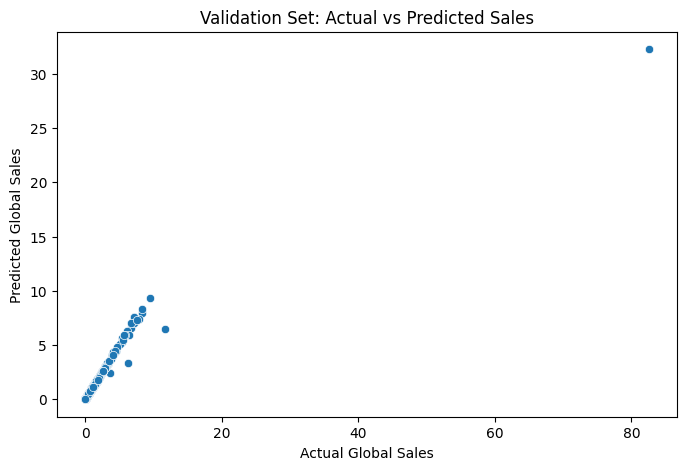

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_val, y=y_val_pred)
plt.xlabel("Actual Global Sales")
plt.ylabel("Predicted Global Sales")
plt.title("Validation Set: Actual vs Predicted Sales")
plt.show()


# Hyperparameter Tuning for CatBoost Model

In [17]:
# Define Parameter Grid

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200]
}

In [18]:
# Wrap CatBoost for sklearn compatibility

cat_model = CatBoostRegressor(verbose=0, random_state=42)

In [19]:
# Use GridSearchCV

grid = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)


,estimator,<catboost.cor...00209F165CF50>
,param_grid,"{'depth': [4, 6, ...], 'iterations': [100, 200], 'learning_rate': [0.01, 0.05, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [20]:
# Best Parameters and Model

print("Best Parameters:", grid.best_params_)
best_cat_model = grid.best_estimator_


Best Parameters: {'depth': 4, 'iterations': 200, 'learning_rate': 0.1}


In [21]:
# Evaluate Tuned Model

# Predict
y_train_pred_tuned = best_cat_model.predict(X_train)
y_val_pred_tuned = best_cat_model.predict(X_val)
y_test_pred_tuned = best_cat_model.predict(X_test)

# Evaluate
evaluate_regression(y_train, y_train_pred_tuned, "Train Set (Tuned)")
evaluate_regression(y_val, y_val_pred_tuned, "Validation Set (Tuned)")
evaluate_regression(y_test, y_test_pred_tuned, "Test Set (Tuned)")



== Train Set (Tuned) Evaluation ==
MAE  : 0.0311
RMSE : 0.0531
R2   : 0.9991

== Validation Set (Tuned) Evaluation ==
MAE  : 0.1026
RMSE : 1.7394
R2   : 0.6719

== Test Set (Tuned) Evaluation ==
MAE  : 0.0465
RMSE : 0.2143
R2   : 0.9826


### Interpretation


| Dataset        | Metric | Untuned | Tuned (GridSearchCV) | Comment                                                 |
| -------------- | ------ | ------- | -------------------- | ------------------------------------------------------- |
| **Train**      | MAE    | 0.0093  | 0.0311               | ↑ Error increased slightly → tuning adds regularization |
|                | RMSE   | 0.0129  | 0.0531               | ↑ Higher, but still very low                            |
|                | R²     | 0.9999  | 0.9991               | ↓ Slight drop → not a concern                           |
| **Validation** | MAE    | 0.0850  | 0.1026               | ↑ Error increased                                       |
|                | RMSE   | 1.7080  | 1.7394               | ↑ Slightly worse                                        |
|                | R²     | 0.6837  | 0.6719               | ↓ Slight decrease                                       |
| **Test**       | MAE    | 0.0308  | 0.0465               | ↑ Slightly worse                                        |
|                | RMSE   | 0.2340  | 0.2143               | ↓ Actually better RMSE                                  |
|                | R²     | 0.9793  | 0.9826               | ↑ Better generalization                                 |


- Before tuning, the model might have been slightly overfitting, especially to the training set.
- Tuning helps the model generalize better, even if the training error increases. This is normal and desirable.
- R² on test set improved from 0.9793 -> 0.9826, meaning the tuned model predicts better on unseen data.

So,

Initial model (untuned):
- Had excellent training performance (R² = 0.9999)
- Validation performance was decent (R² = 0.6837)
- Test performance was strong (R² = 0.9793)

Tuned model:
- Slightly worse training/validation error (normal!)
- Better test R² = 0.9826 -> Better generalization to unseen data 

## Save the final tuned model

In [25]:
import joblib

joblib.dump(best_cat_model, "../../models/fc110570_catboost_tuned_model.pkl")
print("Tuned CatBoost model saved.")


Tuned CatBoost model saved.
